# 🤖 EfficientNetB0 Transfer Learning – KAGGLE DATASET

**Binary myopia classification from Kaggle fundus images**

This notebook converts the transfer learning script provided by the tutor (Abraham Otero) into a cleaner Jupyter Notebook format.  
The model uses **EfficientNetB0 pretrained on ImageNet** as a feature extractor and adds a custom binary classification head for myopia detection.

The training is performed in one stage:

1. **Stage 1 – frozen EfficientNetB0:** only the custom classification head is trained.

The loss function is **Binary Focal Crossentropy**, which gives more importance to difficult examples and to the positive class (Myopia).


-> Stage 1 es el modelo más “puro” de transfer learning: EfficientNetB0 está congelado y solo se entrena la cabeza nueva de clasificación/regresión. Es decir, se usa EfficientNetB0 como extractor fijo de características.

Stage 2-5 son pruebas de fine-tuning: se carga el modelo anterior, se descongela parte de EfficientNetB0 y se deja que algunas capas finales también aprendan con nuestras imágenes de retina.

## 🧠 0. What is and why transfer learning?

Transfer learning means using a neural network that has already learned useful visual patterns from a large dataset, in this case **ImageNet**, and adapting it to a new task.

Here, EfficientNetB0 already contains convolutional filters able to detect general image features such as edges, textures, shapes and local patterns. Instead of training all those filters from zero, we reuse them and train only a small custom head on top. Then, in later stages, we progressively unfreeze some of the final EfficientNetB0 layers so the model can adapt more specifically to fundus images.

This notebook evaluates a transfer learning classification model based on EfficientNetB0 using the Kaggle image set. Unlike the previous small CNN and ResNet notebooks, this model starts from ImageNet-pretrained visual features and then progressively fine-tunes deeper EfficientNetB0 layers across five stages.

This is useful because it tests whether the weak classification results obtained with the previous CNNs were due to insufficient feature extraction. If transfer learning performs better, then pretrained visual representations may be helping the model detect more informative retinal patterns. If not, then the limitation is more likely related to the dataset, labels, preprocessing or task definition.

What is more, the idea is to test whether, with pictures that provide more signal (the Kaggle ones) we obtain more relevant results than with the Galdós dataset.


## ⚙️ 1. Imports and reproducibility


In [1]:
from __future__ import annotations

#import argparse - not needed
import importlib
import sys
from pathlib import Path
from types import SimpleNamespace #extra addition
from typing import Any

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc,
)
#from sklearn.model_selection import train_test_split - we import now
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt #extra addition


#extra addition ----------------------------------------
SEED = 42 #
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception as e:
    print("Determinism could not be enabled:", e)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


## 🧾 2. Experiment configuration

These values can be adapteed if a different experiment is wanted (adapting the number of epochs, batch size...)

Important detail: this EfficientNetB0 implementation keeps images in the **0–255 pixel range**. This is different from some of the previous notebooks where images were converted to **0–1**.


In [2]:
# Experiment selected in config.yaml
EXPERIMENT = "full_preproc"

# Model/loss settings
HEAD = "mlp"
EFFICIENTNET_WEIGHTS = "imagenet"
FOCAL_ALPHA = 0.75
FOCAL_GAMMA = 2.0
THRESHOLD = 0.5

# Training settings - extra addition (#)
EPOCHS = 50 #
BATCH_SIZE_OVERRIDE = 16 # - Use None to read batch size from config.yaml
BASE_LEARNING_RATE = 1e-4 #
EARLY_STOPPING_PATIENCE = 5 #
REDUCE_LR_PATIENCE = 5 #
VERBOSE = 2 #

# Optional: force a project root manually if automatic detection fails.
# Example: PROJECT_ROOT_OVERRIDE = r"C:/Users/Paula/Desktop/TFG_Biomed"
PROJECT_ROOT_OVERRIDE = None # Extra addition

STAGES = [
    {
        "stage": 1,
        "name": "stage1_frozen",
        "unfreeze_last_n_layers": 0,
        "lr_multiplier": 1.0,
    },
#    {
#        "stage": 2,
#        "name": "stage2_unfreeze20",
#        "unfreeze_last_n_layers": 20,
#        "lr_multiplier": 0.1,
#    },
#    {
#        "stage": 3,
#        "name": "stage3_unfreeze40",
#        "unfreeze_last_n_layers": 40,
#        "lr_multiplier": 0.01,
#    },
#    {
#        "stage": 4,
#        "name": "stage4_unfreeze60",
#        "unfreeze_last_n_layers": 60,
#        "lr_multiplier": 0.005,
#    },
#    {
#        "stage": 5,
#        "name": "stage5_unfreeze80",
#        "unfreeze_last_n_layers": 80,
#        "lr_multiplier": 0.002,
#    },
]

#extra addition
args = SimpleNamespace(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_OVERRIDE,
    learning_rate=BASE_LEARNING_RATE,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    reduce_lr_patience=REDUCE_LR_PATIENCE,
    verbose=VERBOSE,
)

# For Kaggle pics:
USE_KAGGLE_PICTURES = True
KAGGLE_IMAGES_ROOT = Path(
    r"C:\Users\paula\0B_TFGBiomed_Exe\Images\03_FullPreprocessing_KagglePictures"
)

## 📁 3. Project paths

This cell searches for `config.yaml` and imports the helper functions from `src.paths`.

The notebook should be run from inside the project folder, or if failing, set `PROJECT_ROOT_OVERRIDE` in the previous cell.


In [3]:
def find_project_root(start: Path | None = None) -> Path: #extra addition: fixed for congif.yaml possible failure
    if PROJECT_ROOT_OVERRIDE is not None: 
        root = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if not (root / "config.yaml").exists():
            raise FileNotFoundError(f"config.yaml was not found in PROJECT_ROOT_OVERRIDE: {root}")
        return root

    root = (start or Path.cwd()).resolve()
    while not (root / "config.yaml").exists():
        if root == root.parent:
            raise FileNotFoundError(
                "config.yaml was not found. Run this notebook from inside the project "
                "or set PROJECT_ROOT_OVERRIDE in the configuration cell."
            )
        root = root.parent
    return root

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

importlib.invalidate_caches()

from src.paths import (  # noqa: E402
    get_experiment_paths,
    get_paths,
    load_config,
    validate_experiment_paths,
    validate_main_structure,
)

In [4]:
# parse_args function would be here, but I believe there is no longer need for it
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Train only the FullPreproc binary myopia classification model."
    )
    parser.add_argument("--epochs", type=int, default=10)
    parser.add_argument("--batch-size", type=int, default=None)
    parser.add_argument("--learning-rate", type=float, default=1e-4)
    parser.add_argument(
        "--early-stopping-patience",
        type=int,
        default=15,
        help="Epochs without val_auc improvement before stopping training.",
    )
    parser.add_argument(
        "--reduce-lr-patience",
        type=int,
        default=5,
        help="Epochs without val_auc improvement before reducing the learning rate.",
    )
    parser.add_argument(
        "--verbose",
        type=int,
        choices=[0, 1, 2],
        default=1,
        help="Keras console verbosity: 0=silent, 1=progress bar, 2=one line per epoch.",
    )
    return parser.parse_args()


In [5]:
# These are extra additions to read variables from config.yaml

cfg = load_config(PROJECT_ROOT / "config.yaml")
paths = get_paths(cfg)
validate_main_structure(paths)

exp_paths = get_experiment_paths(cfg, EXPERIMENT)
validate_experiment_paths(exp_paths)

seed = int(cfg["settings"].get("seed", SEED))
image_size = tuple(cfg["settings"]["image_size"])
batch_size = args.batch_size or int(cfg["settings"]["batch_size"])

TABLE_PATH = exp_paths["table"]
SPLIT_DIR = exp_paths["split_classification"]
MODELS_DIR = exp_paths["models_experiment"] #from yaml
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Experiment:", EXPERIMENT)
print("Table path:", TABLE_PATH)
print("Classification splits:", SPLIT_DIR)
print("Models output:", MODELS_DIR)
print("Image size:", image_size)
print("Batch size:", batch_size)
print("Seed:", seed)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Experiment: full_preproc
Table path: C:\Users\paula\0B_TFGBiomed_Exe\Tables\MatchTables\Tabla_MatchImagenesConDatosClinicos_FullPreproc.xlsx
Classification splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc
Image size: (224, 224)
Batch size: 16
Seed: 42


In [6]:
#Kaggle:

if USE_KAGGLE_PICTURES:
    TABLE_PATH = None

    SPLIT_DIR = PROJECT_ROOT / "Splits" / "Classification" / "KagglePictures_FullPreproc"
    MODELS_DIR = PROJECT_ROOT / "ModelsToSave" / "WithDropout" / "FullPreproc_KagglePictures"

    KAGGLE_IMAGES_ROOT = KAGGLE_IMAGES_ROOT.resolve()

    if not KAGGLE_IMAGES_ROOT.exists():
        raise FileNotFoundError(f"Kaggle images folder not found: {KAGGLE_IMAGES_ROOT}")

else:
    TABLE_PATH = exp_paths["table"]
    SPLIT_DIR = exp_paths["split_classification"]
    MODELS_DIR = exp_paths["models_experiment"]

SPLIT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Experiment:", EXPERIMENT)
print("Using Kaggle pictures:", USE_KAGGLE_PICTURES)
print("Images root:", KAGGLE_IMAGES_ROOT if USE_KAGGLE_PICTURES else "clinical table")
print("Table path:", TABLE_PATH)
print("Classification splits:", SPLIT_DIR)
print("Models output:", MODELS_DIR)
print("Image size:", image_size)
print("Batch size:", batch_size)
print("Seed:", seed)

Project root: C:\Users\paula\0B_TFGBiomed_Exe
Experiment: full_preproc
Using Kaggle pictures: True
Images root: C:\Users\paula\0B_TFGBiomed_Exe\Images\03_FullPreprocessing_KagglePictures
Table path: None
Classification splits: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\KagglePictures_FullPreproc
Models output: C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\WithDropout\FullPreproc_KagglePictures
Image size: (224, 224)
Batch size: 16
Seed: 42


## 🧹 4. Load and pics 

`class_label = 1` corresponds to **Myopia**, and `class_label = 0` corresponds to **Normal**.


In [7]:
def build_dataframe_from_class_folders(images_root: Path) -> pd.DataFrame:
    images_root = Path(images_root)

    image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]

    rows = []

    class_folders = {
        "normal": 0,
        "myopia": 1,
    }

    for class_name, class_label in class_folders.items():
        class_dir_candidates = [
            p for p in images_root.iterdir()
            if p.is_dir() and class_name.lower() in p.name.lower()
        ]

        if len(class_dir_candidates) == 0:
            raise FileNotFoundError(
                f"No folder containing '{class_name}' was found inside {images_root}"
            )

        class_dir = class_dir_candidates[0]

        image_paths = []
        for ext in image_extensions:
            image_paths.extend(class_dir.rglob(ext))

        print(f"{class_name}: {len(image_paths)} images found in {class_dir}")

        for p in image_paths:
            rows.append({
                "image_path": str(p.resolve()),
                "filename": p.name,
                "patient_id": p.stem,  # no real patient_id available in this dataset
                "class_label": class_label,
                "source_dataset": "KagglePictures",
            })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError(f"No images found in {images_root}")

    df["image_path"] = df["image_path"].astype(str)
    df["filename"] = df["filename"].astype(str)
    df["patient_id"] = df["patient_id"].astype(str)
    df["class_label"] = df["class_label"].astype("int32")

    return df.sample(frac=1, random_state=seed).reset_index(drop=True)

#extra addition: loading the table into a df to show it
if USE_KAGGLE_PICTURES:
    df = build_dataframe_from_class_folders(KAGGLE_IMAGES_ROOT)
else:
    df = load_and_clean_table(TABLE_PATH)

print("Total valid images:", len(df))
print("Pseudo-patients / filenames:", df["patient_id"].nunique())
print("Classification label balance:")
print(df["class_label"].value_counts())
display(df.head())

normal: 450 images found in C:\Users\paula\0B_TFGBiomed_Exe\Images\03_FullPreprocessing_KagglePictures\Normal_images
myopia: 334 images found in C:\Users\paula\0B_TFGBiomed_Exe\Images\03_FullPreprocessing_KagglePictures\Myopia_images
Total valid images: 784
Pseudo-patients / filenames: 784
Classification label balance:
class_label
0    450
1    334
Name: count, dtype: int64


,image_path,filename,patient_id,class_label,source_dataset
0,C:\Users\paula\0B_TFGBiomed_Exe\Images\03_Full...,myopia31718.png,myopia31718,1,KagglePictures
1,C:\Users\paula\0B_TFGBiomed_Exe\Images\03_Full...,myopia31526.png,myopia31526,1,KagglePictures
2,C:\Users\paula\0B_TFGBiomed_Exe\Images\03_Full...,normal3592.png,normal3592,0,KagglePictures
3,C:\Users\paula\0B_TFGBiomed_Exe\Images\03_Full...,myopia32930.png,myopia32930,1,KagglePictures
4,C:\Users\paula\0B_TFGBiomed_Exe\Images\03_Full...,normal21813.png,normal21813,0,KagglePictures


This notebook does not use the clinical matched table. Instead, it builds the dataframe directly from the **deduplicated KagglePictures** folders, using the folder names to assign the binary label: `Normal = 0` and `Myopia = 1`.

The dataset contains **784 images**: **450 normal** images and **334 myopic** images. Therefore, the class distribution is much more balanced than in the clinical dataset used in the previous notebooks, where the normal class was clearly dominant. This is important because accuracy becomes easier to interpret here: a majority-class baseline would be around **57%**, not around 77–78% as in the clinical dataset.

This also means that the results from this notebook should not be interpreted as clinical performance. They are more useful as an **external/sanity-check comparison**: the same transfer learning strategy is tested on the Kaggle-style images to evaluate whether the architecture is capable of learning when the visual separation between classes is stronger.


## ✂️ 5. Patient-level train/validation/test splits

This notebook does create new splits from image-level, not patient (there is no more data than the pics).


In [8]:
from sklearn.model_selection import train_test_split

def create_image_level_splits_from_df(
    df: pd.DataFrame,
    split_dir: Path,
    seed: int,
) -> dict[str, pd.DataFrame]:

    train_df, tmp_df = train_test_split(
        df,
        test_size=0.20,
        stratify=df["class_label"],
        random_state=seed,
        shuffle=True,
    )

    val_df, test_df = train_test_split(
        tmp_df,
        test_size=0.50,
        stratify=tmp_df["class_label"],
        random_state=seed,
        shuffle=True,
    )

    split_dfs = {
        "train": train_df.reset_index(drop=True),
        "val": val_df.reset_index(drop=True),
        "test": test_df.reset_index(drop=True),
    }

    split_dir.mkdir(parents=True, exist_ok=True)

    for split_name, split_df in split_dfs.items():
        out_path = split_dir / f"{split_name}.csv"
        split_df.to_csv(out_path, index=False)
        print(f"Saved {split_name}: {out_path} ({len(split_df)} images)")

    return split_dfs


def load_existing_splits(split_dir: Path) -> dict[str, pd.DataFrame]:
    return {
        split_name: pd.read_csv(split_dir / f"{split_name}.csv")
        for split_name in ["train", "val", "test"]
    }


def assert_no_overlap(split_dfs: dict[str, pd.DataFrame], column: str, name: str) -> None:
    split_sets = {
        split_name: set(split_df[column].astype(str))
        for split_name, split_df in split_dfs.items()
    }

    for left, right in [("train", "val"), ("train", "test"), ("val", "test")]:
        overlap = split_sets[left] & split_sets[right]
        if overlap:
            raise AssertionError(
                f"{name} overlap detected between {left} and {right}: "
                f"{len(overlap)} overlapping values. Example: {list(overlap)[:5]}"
            )

    print(f"OK: no {name} overlap across train/val/test.")


# For this Kaggle folder, splits are image-level because there is no patient_id metadata.
if USE_KAGGLE_PICTURES:
    split_dfs = create_image_level_splits_from_df(
        df=df,
        split_dir=SPLIT_DIR,
        seed=seed,
    )
else:
    split_dfs = load_existing_splits(SPLIT_DIR)


required_cols = {"image_path", "class_label"}

for split_name, split_df in split_dfs.items():
    missing_cols = required_cols - set(split_df.columns)
    if missing_cols:
        raise ValueError(f"{split_name} split is missing columns: {missing_cols}")

    print(
        f"{split_name}: {len(split_df)} images, "
        f"{split_df['class_label'].value_counts().to_dict()}"
    )

assert_no_overlap(split_dfs, "image_path", "image")

print("\nClassification balance:")
for split_name, split_df in split_dfs.items():
    print(f"\n{split_name}")
    print(split_df["class_label"].value_counts(normalize=True))
    print(split_df["class_label"].value_counts())

Saved train: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\KagglePictures_FullPreproc\train.csv (627 images)
Saved val: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\KagglePictures_FullPreproc\val.csv (78 images)
Saved test: C:\Users\paula\0B_TFGBiomed_Exe\Splits\Classification\KagglePictures_FullPreproc\test.csv (79 images)
train: 627 images, {0: 360, 1: 267}
val: 78 images, {0: 45, 1: 33}
test: 79 images, {0: 45, 1: 34}
OK: no image overlap across train/val/test.

Classification balance:

train
class_label
0    0.574163
1    0.425837
Name: proportion, dtype: float64
class_label
0    360
1    267
Name: count, dtype: int64

val
class_label
0    0.576923
1    0.423077
Name: proportion, dtype: float64
class_label
0    45
1    33
Name: count, dtype: int64

test
class_label
0    0.56962
1    0.43038
Name: proportion, dtype: float64
class_label
0    45
1    34
Name: count, dtype: int64


The split contains **627 training images**, **78 validation images** and **79 test images**, maintaining the same approximate class balance in the three subsets. The test set contains **45 normal** and **34 myopic** images, so it is reasonably balanced for binary classification.

The notebook confirms that there is no image overlap across train, validation and test. However, this is an **image-level split**, not a true patient-level split, because the Kaggle dataset does not provide real patient identifiers. The `patient_id` field is only a pseudo-identifier generated from the filename.

This makes the evaluation valid for checking image-level generalization within this Kaggle subset, but it should not be interpreted in the same way as a clinical patient-level split. Compared with the clinical notebooks, this dataset is cleaner from a classification-label perspective, but less clinically rich because it does not include SE values, patient variables, eye laterality or acquisition modality.


## 🧮 6. TensorFlow datasets

This dataloader reads image paths from the split CSV files.

Unlike previous notebooks where images were converted to `[0, 1]`, here images are only cast to `float32`, keeping their values in the `[0, 255]` range before entering EfficientNetB0.


In [9]:
def resolve_project_path(path: str | Path) -> Path:
    path = Path(path)
    if path.is_absolute():
        return path
    return PROJECT_ROOT / path

def resolve_project_path_str(path: str | Path) -> str:
    return str(resolve_project_path(path))

def make_datasets(
    split_dir: Path,
    image_size: tuple[int, int],
    batch_size: int,
    seed: int,
) -> tuple[tf.data.Dataset, tf.data.Dataset, tf.data.Dataset]:
    autotune = tf.data.AUTOTUNE
    shuffle_buffer_size = 2048

    augment = keras.Sequential( #extra: augmentations before decode_img
        [
            layers.RandomFlip("horizontal"),
            layers.RandomRotation(0.02),
            layers.RandomZoom(0.05),
        ],
        name="light_augmentation",
    )

    def decode_img(path, y):
        img_bytes = tf.io.read_file(path)
        img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
        img = tf.ensure_shape(img, [None, None, 3])
        img = tf.image.resize(img, image_size, method="bilinear")
        img = tf.cast(img, tf.float32)  # Keep pixel range 0-255 for EfficientNetB0
        return img, tf.cast(y, tf.float32)

    def make_classification_ds(csv_path: Path, training: bool = False) -> tf.data.Dataset:
        df_split = pd.read_csv(csv_path)
        paths = df_split["image_path"].map(resolve_project_path_str).astype(str).values
        labels = df_split["class_label"].astype("float32").values

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        ds = ds.map(decode_img, num_parallel_calls=autotune)

        if training:
            ds = ds.shuffle(
                shuffle_buffer_size,
                seed=seed,
                reshuffle_each_iteration=True,
            )
            ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=autotune)

        return ds.batch(batch_size).prefetch(autotune)

    return (
        make_classification_ds(split_dir / "train.csv", training=True),
        make_classification_ds(split_dir / "val.csv", training=False),
        make_classification_ds(split_dir / "test.csv", training=False),
    )

#extra: splitting here and now...
train_ds, val_ds, test_ds = make_datasets(
    split_dir=SPLIT_DIR,
    image_size=image_size,
    batch_size=batch_size,
    seed=seed,
)

#... and checking performance before moving on
for xb, yb in train_ds.take(1):
    print("Batch image shape:", xb.shape)
    print("Batch label shape:", yb.shape)
    print("Pixel range in batch:", float(tf.reduce_min(xb)), "to", float(tf.reduce_max(xb)))


Batch image shape: (16, 224, 224, 3)
Batch label shape: (16,)
Pixel range in batch: 0.0 to 255.0


## 🧩 7. EfficientNetB0 model definition

EfficientNetB0 is used without its original classification layer (`include_top=False`).

The custom head is:

`GlobalAveragePooling2D → BatchNormalization → Dense(256, ReLU) → Dropout(0.4) → Dense(64, ReLU) → Dropout(0.2) → Dense(1, sigmoid)`

In [10]:
def configure_efficientnet_base_trainability( #switching this function to top of cell bc function below uses it (no need, but maked more sense "chronologically")
    base_model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")

    base_model.trainable = bool(unfreeze_last_n_layers)

    # Freeze everything first
    for layer in base_model.layers:
        layer.trainable = False

    if not unfreeze_last_n_layers:
        return

    # BatchNorm layers are kept frozen during fine-tuning for stability
    trainable_layers = [
        layer
        for layer in base_model.layers
        if not isinstance(layer, layers.BatchNormalization)
    ]

    for layer in trainable_layers[-unfreeze_last_n_layers:]:
        layer.trainable = True

def build_efficientnetb0_classification(
    input_shape: tuple[int, int, int],
    unfreeze_last_n_layers: int,
) -> keras.Model:
    if unfreeze_last_n_layers < 0:
        raise ValueError("unfreeze_last_n_layers must be >= 0.")
    
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights=EFFICIENTNET_WEIGHTS,
        input_shape=input_shape,
    )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)

    inputs = keras.Input(shape=input_shape)
    features = base_model(inputs, training=bool(unfreeze_last_n_layers))
    x = layers.GlobalAveragePooling2D()(features)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inputs, outputs, name="efficientnetb0_classification")

def find_efficientnet_base(model: keras.Model) -> keras.Model | None:
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name.startswith("efficientnet"):
            return layer
    return None


def configure_loaded_model_for_fine_tuning(
    model: keras.Model,
    unfreeze_last_n_layers: int,
) -> None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        raise ValueError(
            "The loaded model does not contain an EfficientNet base. "
            "Check the previous stage model path."
        )
    configure_efficientnet_base_trainability(base_model, unfreeze_last_n_layers)


def count_trainable_base_layers(model: keras.Model) -> int | None:
    base_model = find_efficientnet_base(model)
    if base_model is None:
        return None
    return sum(
        1
        for layer in base_model.layers
        if layer.trainable and not isinstance(layer, layers.BatchNormalization)
    )


In [11]:
#These fucntions were supposed to be here, but I believe there's no need for them anymore:
def build_classification_model(
    input_shape: tuple[int, int, int],
    unfreeze_last_n_layers: int,
) -> keras.Model:
    return build_efficientnetb0_classification(
        input_shape=input_shape,
        unfreeze_last_n_layers=unfreeze_last_n_layers,
    )

## 🎯 8. Loss, optimizer, callbacks and metrics


In [12]:
def build_loss() -> keras.losses.Loss:
    return keras.losses.BinaryFocalCrossentropy(
        alpha=FOCAL_ALPHA,
        gamma=FOCAL_GAMMA,
        apply_class_balancing=True,
    )

def compile_model(model: keras.Model, learning_rate: float) -> None:
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=build_loss(),
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"],
    )

#Extra: moving this function up here (makes sense chronologically)
class EpochConsoleLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch: int, logs: dict[str, Any] | None = None) -> None:
        logs = logs or {}
        lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        metric_names = ["loss", "auc", "accuracy", "val_loss", "val_auc", "val_accuracy"]
        metrics = []

        for name in metric_names:
            if name in logs:
                metrics.append(f"{name}={float(logs[name]):.6f}")

        metrics.append(f"lr={lr:.2e}")
        print(f"Epoch {epoch + 1}: " + " | ".join(metrics), flush=True)


def make_callbacks(args: SimpleNamespace) -> list[keras.callbacks.Callback]:
    return [
        EpochConsoleLogger(),
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=args.early_stopping_patience,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.3,
            patience=args.reduce_lr_patience,
        ),
    ]


## 📊 9. Evaluation helpers

These functions calculate AUC, AP, accuracy, recall for myopia, confusion matrix and classification report.


In [13]:
def collect_classification_preds(
    model: keras.Model,
    ds: tf.data.Dataset,
) -> tuple[np.ndarray, np.ndarray]:
    y_true, y_score = [], []

    for xb, yb in ds:
        p = model.predict(xb, verbose=0).ravel()
        y_true.extend(yb.numpy().tolist())
        y_score.extend(p.tolist())

    return np.array(y_true).astype(int), np.array(y_score).astype(float)

def evaluate_classification( model: keras.Model, test_ds: tf.data.Dataset, threshold: float = THRESHOLD) -> dict[str, Any]:
    y_true, y_score = collect_classification_preds(model, test_ds)
    y_pred = (y_score >= threshold).astype(int)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ap = average_precision_score(y_true, y_score)
    cm = confusion_matrix(y_true, y_pred)

    report = classification_report(
        y_true,
        y_pred,
        target_names=["Normal", "Myopia"],
        output_dict=True,
        zero_division=0, #helps for errors found on previous notebooks with 0 division, when plotting
    )

    print(classification_report(y_true, y_pred, target_names=["Normal", "Myopia"], zero_division=0))
    print("Confusion matrix:\n", cm)
    print(f"AUC: {roc_auc:.6f}")
    print(f"AP: {ap:.6f}")
    print(f"Accuracy@{threshold}: {(y_pred == y_true).mean():.6f}")

    return { #added a couple more vars to return (#)
        "auc": float(roc_auc),
        "average_precision": float(ap),
        f"accuracy@{threshold}": float((y_pred == y_true).mean()),
        "recall_myopia": float(report["Myopia"]["recall"]), #
        "precision_myopia": float(report["Myopia"]["precision"]), #
        "confusion_matrix": cm.tolist(),
        "classification_report": report,
        "fpr": fpr.tolist(), #
        "tpr": tpr.tolist(), #
        "precision_curve": precision.tolist(),
        "recall_curve": recall.tolist(),
        "y_true": y_true.tolist(), #
        "y_score": y_score.tolist(), #
        "y_pred": y_pred.tolist(), #
    }


## 💾 10. Output paths and stage training function


In [14]:
#extra addition: one route per stage (per model)
def stage_output_paths(models_dir: Path, stage: dict[str, Any]) -> tuple[Path, Path, Path]:
    stem = f"transfer_learning_classification_with_dropout_fullpreproc_{stage['name']}"
    
    stage_model_path = models_dir / f"{stem}.keras"
    stage_summary_path = models_dir / f"{stem}_summary.json"
    stage_preds_path = models_dir / f"{stem}_predictions.csv"
    
    return stage_model_path, stage_summary_path, stage_preds_path

def train_stage( #extra: moved here for chr. sense
    stage: dict[str, Any],
    args: SimpleNamespace,
    input_shape: tuple[int, int, int],
    train_ds: tf.data.Dataset,
    val_ds: tf.data.Dataset,
    test_ds: tf.data.Dataset,
    models_dir: Path,
    previous_model_path: Path | None,
    common_summary: dict[str, Any],
) -> tuple[dict[str, Any], dict[str, list[float]]]:
    stage_model_path, stage_summary_path, stage_preds_path = stage_output_paths(models_dir, stage)    
    stage_lr = args.learning_rate * float(stage["lr_multiplier"])
    unfreeze_last_n_layers = int(stage["unfreeze_last_n_layers"])

    print("\n" + "=" * 72)
    print(f"Stage {stage['stage']}: {stage['name']}")
    print("Initial model:", previous_model_path)
    print("Unfreeze last N EfficientNetB0 layers:", unfreeze_last_n_layers)
    print("Learning rate:", stage_lr)
    print("Epochs requested:", args.epochs)
    print("=" * 72)

    if previous_model_path is None:
        model = build_efficientnetb0_classification(
            input_shape=input_shape,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )
    else:
        model = keras.models.load_model(previous_model_path, compile=False)
        configure_loaded_model_for_fine_tuning(
            model=model,
            unfreeze_last_n_layers=unfreeze_last_n_layers,
        )

    trainable_base_layers = count_trainable_base_layers(model)
    print("EfficientNetB0 trainable base layers:", trainable_base_layers)

    compile_model(model, stage_lr)
    model.summary()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=args.epochs,
        callbacks=make_callbacks(args),
        verbose=args.verbose,
    )

    print("Keras test metrics:")
    keras_metrics = model.evaluate(test_ds, return_dict=True)
    print(keras_metrics)

    eval_metrics = evaluate_classification(model, test_ds, threshold=THRESHOLD)

    preds_df = pd.DataFrame({ #extra: for later (possibility for saving below as well)
        "y_true": eval_metrics["y_true"],
        "y_score": eval_metrics["y_score"],
        "y_pred": eval_metrics["y_pred"],
    })
    #preds_df.to_csv(stage_preds_path, index=False)
    #print("Stage predictions saved at:", stage_preds_path)

    model.save(stage_model_path)
    print("Stage model saved at:", stage_model_path)

    stage_summary = {
        **common_summary,
        "stage": stage["stage"],
        "stage_name": stage["name"],
        "model_path": str(stage_model_path),
        "predictions_path": str(stage_preds_path),
        "initial_model_path": str(previous_model_path) if previous_model_path else None,
        "learning_rate": stage_lr,
        "base_learning_rate": args.learning_rate,
        "lr_multiplier": float(stage["lr_multiplier"]),
        "unfreeze_last_n_layers": unfreeze_last_n_layers,
        "trainable_base_layers": trainable_base_layers,
        "epochs_requested": args.epochs,
        "epochs_run": len(history.history.get("loss", [])),
        "best_val_auc": float(np.max(history.history.get("val_auc", [np.nan]))),
        "best_val_accuracy": float(np.max(history.history.get("val_accuracy", [np.nan]))),
        "keras_test_metrics": {k: float(v) for k, v in keras_metrics.items()},
        "evaluation": {
            k: v for k, v in eval_metrics.items()
            if k not in {"y_true", "y_score", "y_pred"}
        },
    }

    return stage_summary, history.history #returnign history as well for plotting


## 🚀 11. Run the 1 training stage

This cell trains the full staged pipeline (what would've been the "main function").  



In [15]:
input_shape = (*image_size, 3)

common_summary = {
    "table_path": str(TABLE_PATH) if TABLE_PATH is not None else None,
    "image_root": str(KAGGLE_IMAGES_ROOT) if USE_KAGGLE_PICTURES else None,
    "split_level": "image",
    "source_dataset": "KagglePictures",
    "split_dir": str(SPLIT_DIR),
    "experiment": EXPERIMENT,
    "image_size": list(image_size),
    "batch_size": batch_size,
    "seed": seed,
    "architecture": "efficientnetb0",
    "head": HEAD,
    "efficientnet_weights": EFFICIENTNET_WEIGHTS,
    "image_pixel_range": "0-255",
    "loss": "binary_focal_crossentropy",
    "focal_alpha": FOCAL_ALPHA,
    "focal_gamma": FOCAL_GAMMA,
    "threshold": THRESHOLD,
}

stage_summaries = []
stage_histories = {}
previous_model_path = None

for stage in STAGES:
    stage_summary, stage_history = train_stage(
        stage=stage,
        args=args,
        input_shape=input_shape,
        train_ds=train_ds,
        val_ds=val_ds,
        test_ds=test_ds,
        models_dir=MODELS_DIR,
        previous_model_path=previous_model_path,
        common_summary=common_summary,
    )

    stage_summaries.append(stage_summary)
    stage_histories[stage["name"]] = stage_history
    previous_model_path = Path(stage_summary["model_path"])

global_summary = {
    **common_summary,
    "base_learning_rate": args.learning_rate,
    "epochs_requested_per_stage": args.epochs,
    "stages": stage_summaries,
}


Stage 1: stage1_frozen
Initial model: None
Unfreeze last N EfficientNetB0 layers: 0
Learning rate: 0.0001
Epochs requested: 50
EfficientNetB0 trainable base layers: 0


Model: "efficientnetb0_classification"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1280)                │           5,120 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/50
Epoch 1: loss=0.119743 | auc=0.764191 | accuracy=0.695375 | val_loss=0.035883 | val_auc=0.978451 | val_accuracy=0.820513 | lr=1.00e-04
40/40 - 38s - 953ms/step - accuracy: 0.6954 - auc: 0.7642 - loss: 0.1197 - val_accuracy: 0.8205 - val_auc: 0.9785 - val_loss: 0.0359 - learning_rate: 1.0000e-04
Epoch 2/50
Epoch 2: loss=0.046112 | auc=0.924792 | accuracy=0.837321 | val_loss=0.026193 | val_auc=0.988215 | val_accuracy=0.884615 | lr=1.00e-04
40/40 - 20s - 512ms/step - accuracy: 0.8373 - auc: 0.9248 - loss: 0.0461 - val_accuracy: 0.8846 - val_auc: 0.9882 - val_loss: 0.0262 - learning_rate: 1.0000e-04
Epoch 3/50
Epoch 3: loss=0.037089 | auc=0.947514 | accuracy=0.856459 | val_loss=0.020923 | val_auc=0.990909 | val_accuracy=0.910256 | lr=1.00e-04
40/40 - 21s - 516ms/step - accuracy: 0.8565 - auc: 0.9475 - loss: 0.0371 - val_accuracy: 0.9103 - val_auc: 0.9909 - val_loss: 0.0209 - learning_rate: 1.0000e-04
Epoch 4/50
Epoch 4: loss=0.025607 | auc=0.968862 | accuracy=0.896332 | val_loss

Only **Stage 1 (`stage1_frozen`)** was actually executed in this notebook. The later fine-tuning stages are present in the code structure but commented out in the configuration cell. Therefore, this experiment evaluates the most direct transfer learning setup: **EfficientNetB0 is kept frozen and only the custom classification head is trained**.

The model has around **4.4 million total parameters**, but only around **347k trainable parameters**. This is important because the result is achieved without adapting the EfficientNetB0 convolutional backbone to the Kaggle retinal images. In other words, the ImageNet-pretrained features are already sufficient to separate the two classes very well in this dataset.

Training ran for **19 epochs** and reached a very high validation AUC, with a best validation AUC of approximately **0.9987**. This is much higher than the validation behaviour observed in the clinical classification notebooks. The difference suggests that the Kaggle images present a more easily separable visual problem than the clinical dataset, rather than simply proving that EfficientNetB0 is universally strong for myopia detection.


## 📋 12. Results table

This table is formatted similarly to the rest of the notebooks: AUC, AP, accuracy and recall for myopia.


In [16]:
results_rows = []

for summary in stage_summaries:
    ev = summary["evaluation"]
    results_rows.append({
        "stage": summary["stage"],
        "stage_name": summary["stage_name"],
        "unfreeze_last_n_layers": summary["unfreeze_last_n_layers"],
        "learning_rate": summary["learning_rate"],
        "epochs_run": summary["epochs_run"],
        "best_val_auc": summary["best_val_auc"],
        "test_auc": ev["auc"],
        "test_ap": ev["average_precision"],
        f"test_accuracy@{THRESHOLD}": ev[f"accuracy@{THRESHOLD}"],
        "test_recall_myopia": ev["recall_myopia"],
        "test_precision_myopia": ev["precision_myopia"],
        "model_path": summary["model_path"],
    })

results_df = pd.DataFrame(results_rows)
display(results_df)


,stage,stage_name,unfreeze_last_n_layers,learning_rate,epochs_run,best_val_auc,test_auc,test_ap,test_accuracy@0.5,test_recall_myopia,test_precision_myopia,model_path
0,1,stage1_frozen,0,0.0001,19,0.998653,0.99281,0.991203,0.936709,0.911765,0.939394,C:\Users\paula\0B_TFGBiomed_Exe\ModelsToSave\W...


The frozen EfficientNetB0 model obtains very strong test results on the Kaggle dataset: **AUC = 0.9928**, **AP = 0.9912**, **accuracy = 0.9367**, **myopia recall = 0.9118** and **myopia precision = 0.9394**.

This is one of the clearest results obtained so far across the notebooks. Unlike the clinical classification experiments, the model is not only ranking the classes well, but it also works well with the default threshold of 0.5. Both the AUC/AP metrics and the threshold-dependent metrics are strong.

Compared with the clinical EfficientNetB0 classification notebook, the improvement is very large. In the clinical dataset, EfficientNetB0 improved the ranking of classes compared with small CNNs, but still remained limited, with AUC values around the low 0.7 range and low precision for myopia. Here, the same general architecture reaches almost perfect ranking. This strongly suggests that the limiting factor in the clinical experiments is not only the architecture, but also the dataset/domain: clinical images are more heterogeneous and probably contain weaker image-only signal for binary myopia classification.

-> Compared with the previous Telecom TFG on Kaggle/blue-fundus-style data, this result is also consistent with the idea that the Kaggle dataset is much easier to classify than the clinical one. The high performance obtained here should therefore be used carefully: it is useful as a positive control, but it should not be transferred directly to conclusions about real clinical deployment.


## 📈 13. Training curves


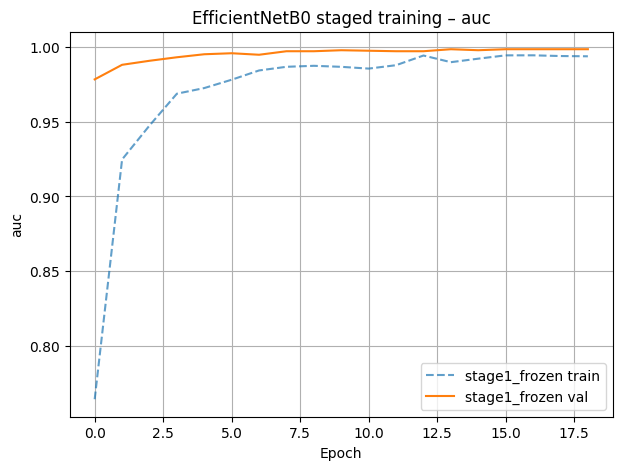

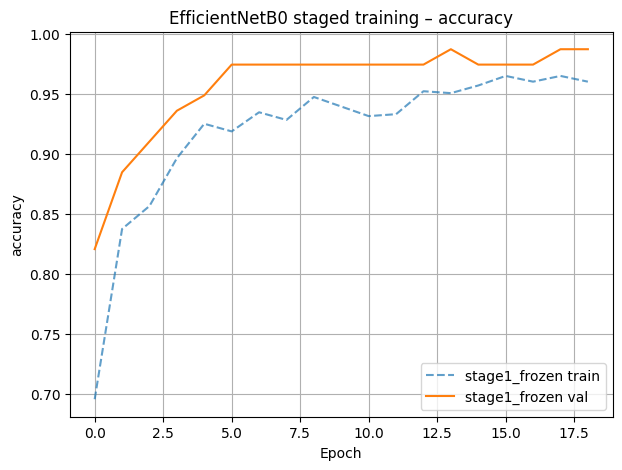

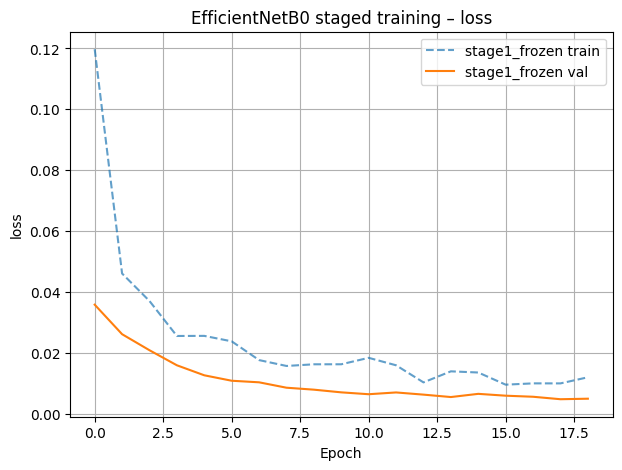

In [17]:
def plot_stage_histories(histories_dict: dict[str, dict[str, list[float]]], metric: str = "auc") -> None:
    plt.figure(figsize=(7, 5))

    for name, history in histories_dict.items():
        if metric in history:
            plt.plot(history[metric], linestyle="--", alpha=0.7, label=f"{name} train")
        if f"val_{metric}" in history:
            plt.plot(history[f"val_{metric}"], label=f"{name} val")

    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.title(f"EfficientNetB0 staged training – {metric}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_stage_histories(stage_histories, metric="auc")
plot_stage_histories(stage_histories, metric="accuracy")
plot_stage_histories(stage_histories, metric="loss")


The AUC and accuracy curves show a rapid and stable learning process. Validation AUC reaches very high values early and remains close to 1, while the training AUC progressively increases until it also becomes very high.

This pattern is very different from the clinical classification notebooks, where the validation curves were much flatter and the model struggled to separate myopic and normal images. Here, the curves indicate that the frozen EfficientNetB0 features are highly informative for this dataset.

However, the validation set contains only **78 images**, so the curves should not be overinterpreted at an epoch-by-epoch level. With such a small validation set, each individual image has a visible effect on validation accuracy. The important conclusion is therefore not the exact best epoch, but the overall fact that the model converges clearly and reaches consistently high validation performance.


## 📉 14. ROC and Precision-Recall curves


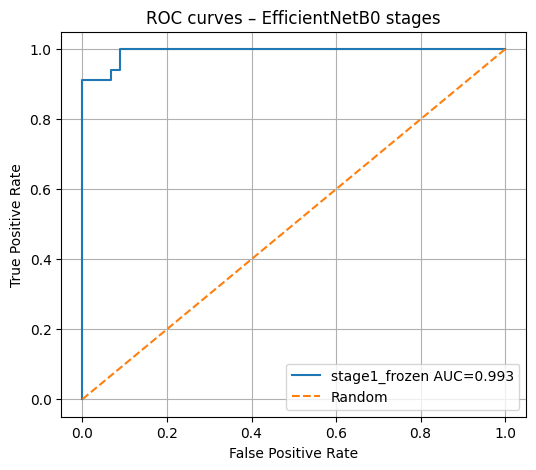

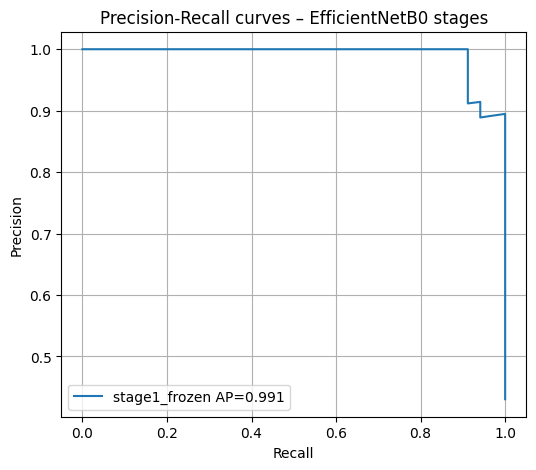

In [18]:
def plot_roc_pr_from_summaries(stage_summaries: list[dict[str, Any]]) -> None:
    plt.figure(figsize=(6, 5))
    for summary in stage_summaries:
        ev = summary["evaluation"]
        plt.plot(ev["fpr"], ev["tpr"], label=f"{summary['stage_name']} AUC={ev['auc']:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curves – EfficientNetB0 stages")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 5))
    for summary in stage_summaries:
        ev = summary["evaluation"]
        plt.plot(ev["recall_curve"], ev["precision_curve"], label=f"{summary['stage_name']} AP={ev['average_precision']:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curves – EfficientNetB0 stages")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_roc_pr_from_summaries(stage_summaries)

The ROC curve is very close to the top-left corner and the Precision-Recall curve remains high across most recall values. This confirms that the model ranks myopic images above normal images very effectively.

The high AP value is especially relevant because it means the model maintains high precision while recovering most myopic cases. This contrasts with the clinical EfficientNetB0 notebook, where recall was acceptable but precision for myopia remained low. In this Kaggle experiment, the model is not simply overpredicting myopia: **it is identifying both classes with good balance.**


## 🔢 15. Confusion matrices


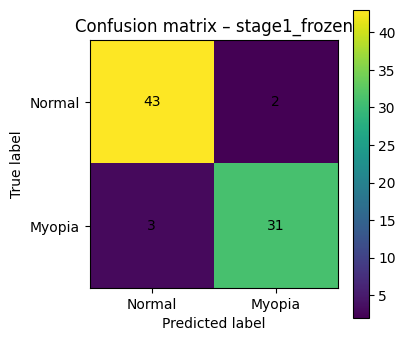

In [19]:
def plot_confusion_matrix(cm: list[list[int]], title: str) -> None:
    cm_arr = np.array(cm)

    plt.figure(figsize=(4, 4))
    plt.imshow(cm_arr)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Normal", "Myopia"])
    plt.yticks([0, 1], ["Normal", "Myopia"])

    for i in range(cm_arr.shape[0]):
        for j in range(cm_arr.shape[1]):
            plt.text(j, i, str(cm_arr[i, j]), ha="center", va="center")

    plt.colorbar()
    plt.show()

for summary in stage_summaries:
    plot_confusion_matrix(
        summary["evaluation"]["confusion_matrix"],
        title=f"Confusion matrix – {summary['stage_name']}",
    )

The confusion matrix shows **43 true normals**, **2 false positives**, **3 false negatives** and **31 true myopic images**. Therefore, the model makes only **5 errors out of 79 test images**.

This corresponds to a normal recall of approximately **95.6%** and a myopia recall of approximately **91.2%**. The performance is balanced across both classes, which is important because it means the high accuracy is not caused by predicting only the majority class.

This behaviour is very different from some previous clinical classification models, where the threshold at 0.5 often caused a strong bias towards either normal or myopia. Here, the default threshold already produces a clinically more interpretable balance between false positives and false negatives.


## 📝 16. Results template (test)

Short text skeleton that can be adapted for the TFG results section.


In [20]:
best_auc_row = results_df.sort_values("test_auc", ascending=False).iloc[0]
best_recall_row = results_df.sort_values("test_recall_myopia", ascending=False).iloc[0]

print("Best stage by AUC:")
print(best_auc_row[["stage_name", "test_auc", f"test_accuracy@{THRESHOLD}", "test_recall_myopia"]])
print("\nBest stage by myopia recall:")
print(best_recall_row[["stage_name", "test_auc", f"test_accuracy@{THRESHOLD}", "test_recall_myopia"]])

Best stage by AUC:
stage_name            stage1_frozen
test_auc                    0.99281
test_accuracy@0.5          0.936709
test_recall_myopia         0.911765
Name: 0, dtype: object

Best stage by myopia recall:
stage_name            stage1_frozen
test_auc                    0.99281
test_accuracy@0.5          0.936709
test_recall_myopia         0.911765
Name: 0, dtype: object


-> Clasificación: Stage 2 mejora AUC mínimamente, pero Stage 1 tiene mejor recall de miopía empleando muchos menos parámetros.

The main result is that the frozen EfficientNetB0 model performs extremely well on this dataset, reaching **AUC = 0.9928**, **AP = 0.9912**, **accuracy = 0.9367**, **myopia recall = 0.9118** and **myopia precision = 0.9394**. The confusion matrix confirms that the model makes only five mistakes on the test set and that performance is balanced between normal and myopic images.

A key point is that this result is obtained with **Stage 1 only**, meaning that the EfficientNetB0 backbone remains frozen and only the classification head is trained. Therefore, additional fine-tuning was not necessary to obtain strong performance on this dataset.

The most important comparison is with the clinical transfer learning notebook. In the clinical dataset, EfficientNetB0 improved over the small CNNs but remained clearly limited, with moderate AUC and low precision for myopia. In contrast, on the Kaggle dataset, the same type of model obtains almost perfect class ranking. This difference suggests that the Kaggle dataset contains stronger or cleaner visual class cues, while the clinical dataset is more heterogeneous and harder to classify from fundus images alone.

Therefore, this notebook should be interpreted as a **positive control** rather than as the final clinical result. It shows that the transfer learning pipeline is technically capable of learning the task when the dataset contains separable visual information. However, the clinical notebooks remain more representative of the real biomedical problem, because they use clinically matched images and patient-derived labels.

-> Overall, these results reinforce one of the main conclusions of the project: **dataset characteristics and clinical realism have a stronger impact on performance than simply increasing model complexity**. A model can perform extremely well on Kaggle-style images and still struggle on real clinical data.
